Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")


Load Dataset

In [10]:
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\Daily Household Transactions.csv")

# Preview data
df.head()


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


Basic Data Inspection

In [11]:
# Shape of dataset
df.shape

# Dataset info
df.info()

# Checking missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

Data Cleaning

In [14]:
# Filling missing values
df["Subcategory"].fillna("Unknown", inplace=True)
df["Note"].fillna("No Description", inplace=True)

# Converting Date column to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)

# Removing duplicates
df.drop_duplicates(inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2452 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2452 non-null   datetime64[ns]
 1   Mode            2452 non-null   object        
 2   Category        2452 non-null   object        
 3   Subcategory     2452 non-null   object        
 4   Note            2452 non-null   object        
 5   Amount          2452 non-null   float64       
 6   Income/Expense  2452 non-null   object        
 7   Currency        2452 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 172.4+ KB


Exploratory Data Analysis (EDA)

Transaction Mode Distribution

In [15]:
df["Mode"].value_counts()


Mode
Saving Bank account 1    1215
Cash                     1045
Credit Card               162
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Debit Card                  2
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64

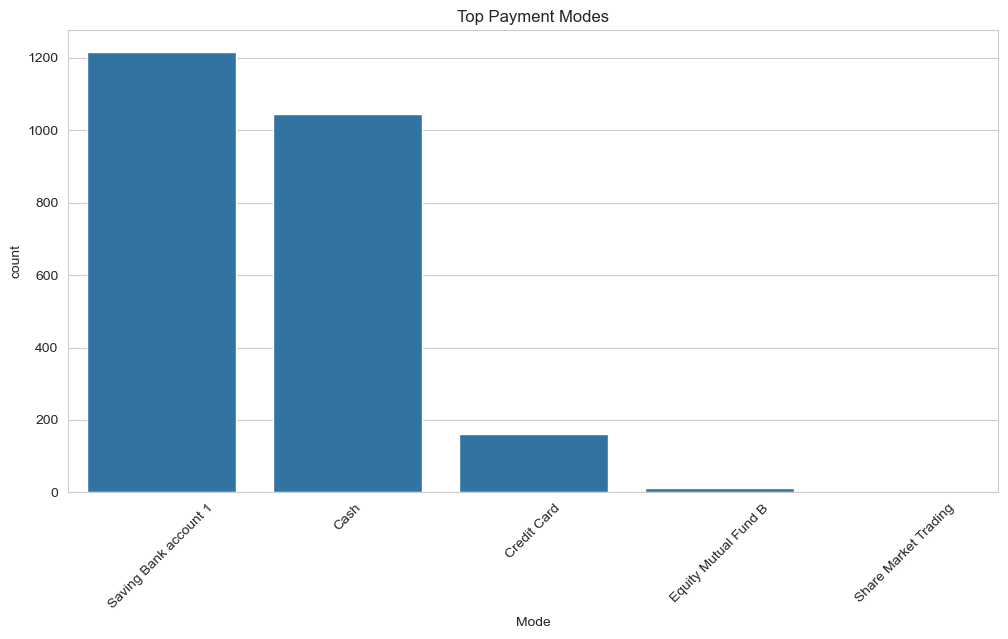

In [16]:
sns.countplot(data=df, x="Mode", order=df["Mode"].value_counts().iloc[:5].index)
plt.xticks(rotation=45)
plt.title("Top Payment Modes")
plt.show()


Category Analysis

In [17]:
df["Category"].value_counts().head(10)


Category
Food              906
Transportation    307
Household         176
subscription      143
Other             126
Investment        101
Health             94
Family             71
Apparel            47
Salary             43
Name: count, dtype: int64

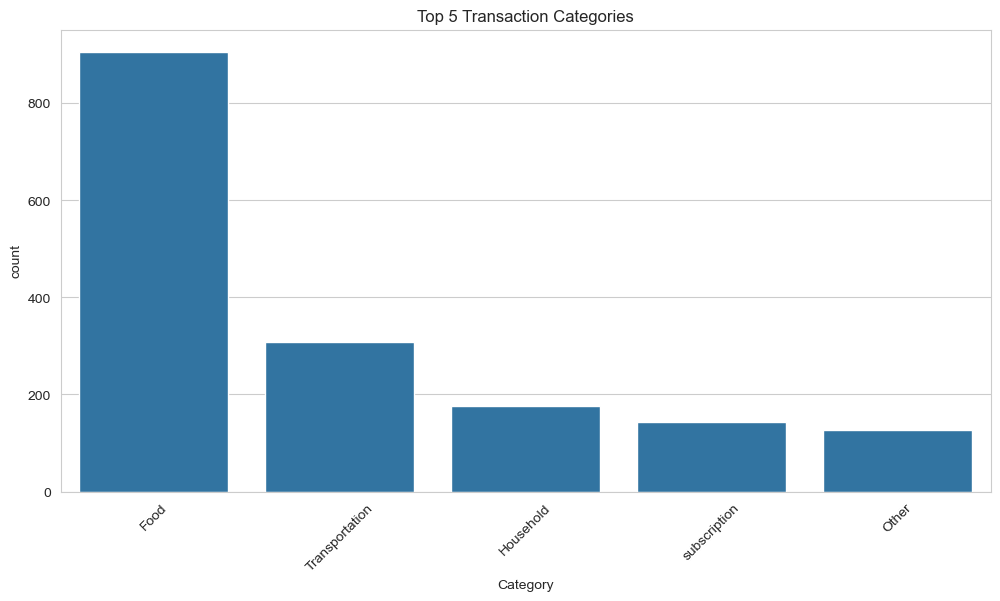

In [18]:
sns.countplot(data=df, x="Category",
              order=df["Category"].value_counts().iloc[:5].index)
plt.xticks(rotation=45)
plt.title("Top 5 Transaction Categories")
plt.show()


Subcategory Analysis

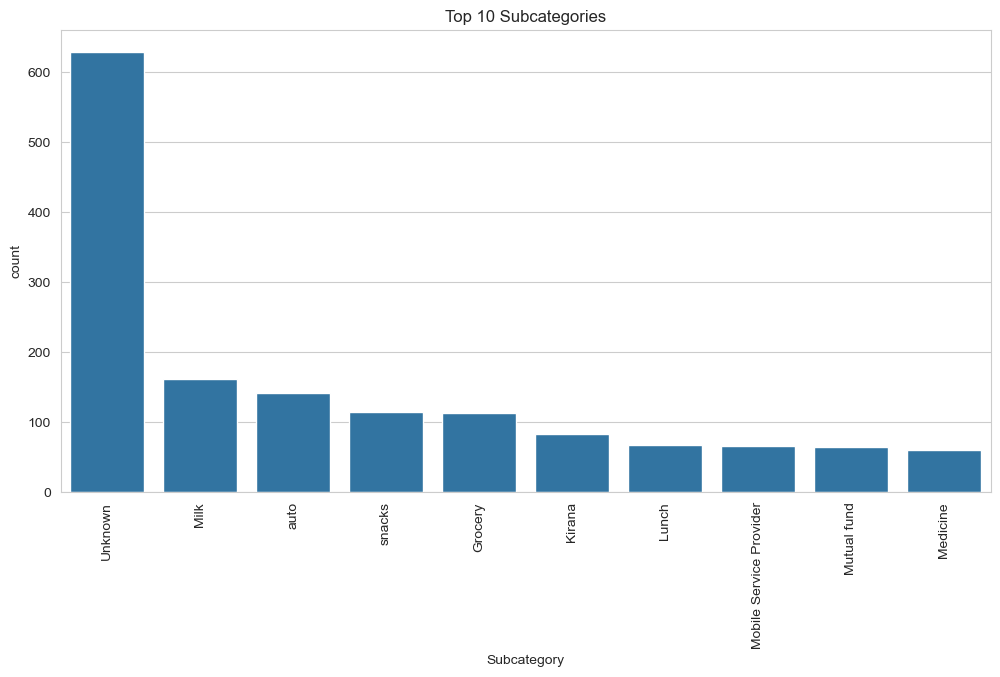

In [19]:
sns.countplot(data=df, x="Subcategory",
              order=df["Subcategory"].value_counts().iloc[:10].index)
plt.xticks(rotation=90)
plt.title("Top 10 Subcategories")
plt.show()


Income vs Expense

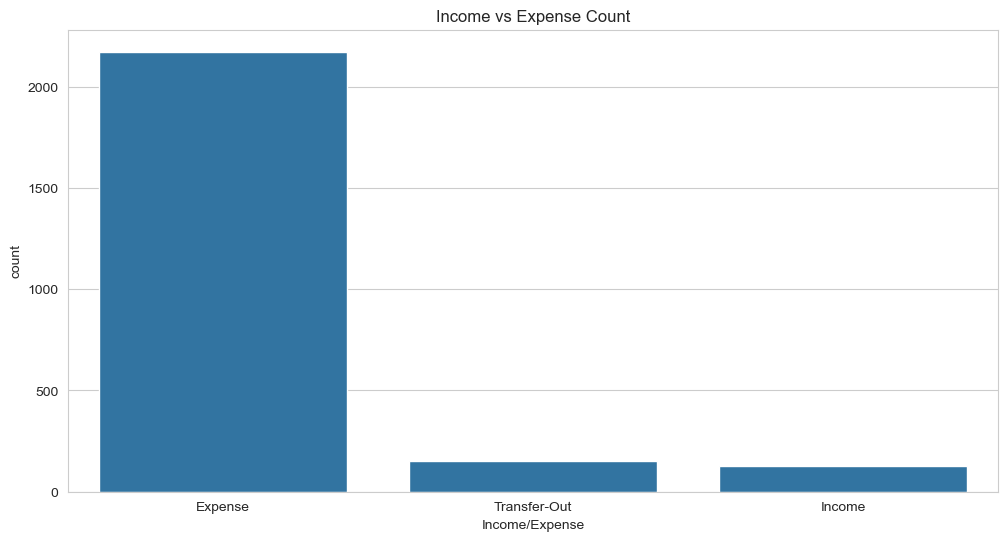

In [20]:
sns.countplot(data=df, x="Income/Expense")
plt.title("Income vs Expense Count")
plt.show()


Amount Analysis

Distribution of Amount

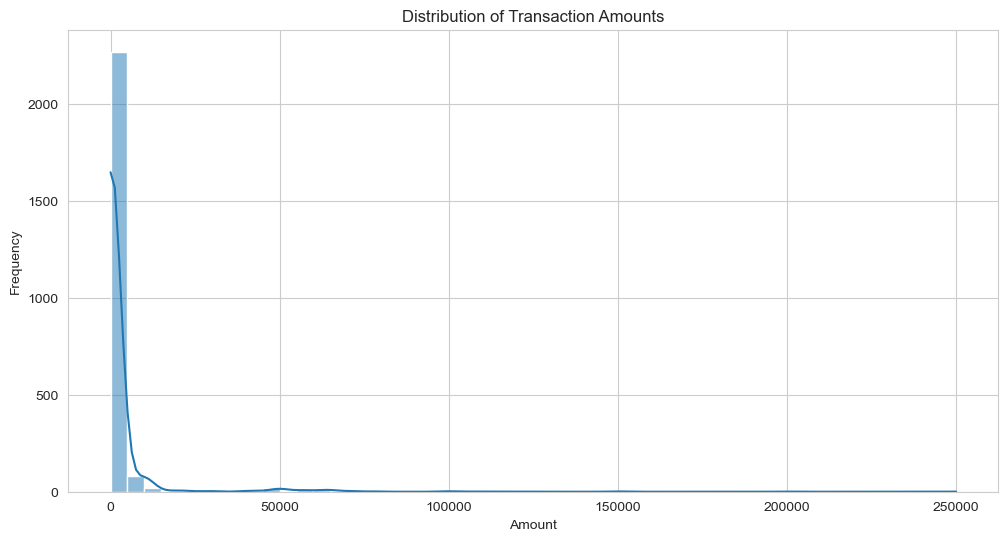

In [21]:
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


Boxplot by Category

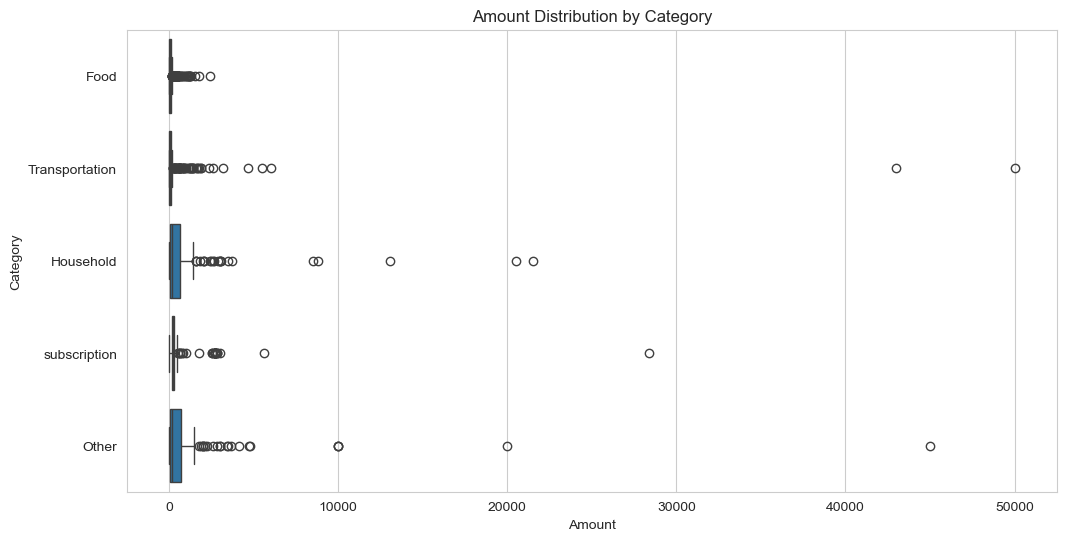

In [22]:
sns.boxplot(data=df, x="Amount", y="Category",
            order=df["Category"].value_counts().iloc[:5].index)
plt.title("Amount Distribution by Category")
plt.show()


Boxplot by Income/Expense

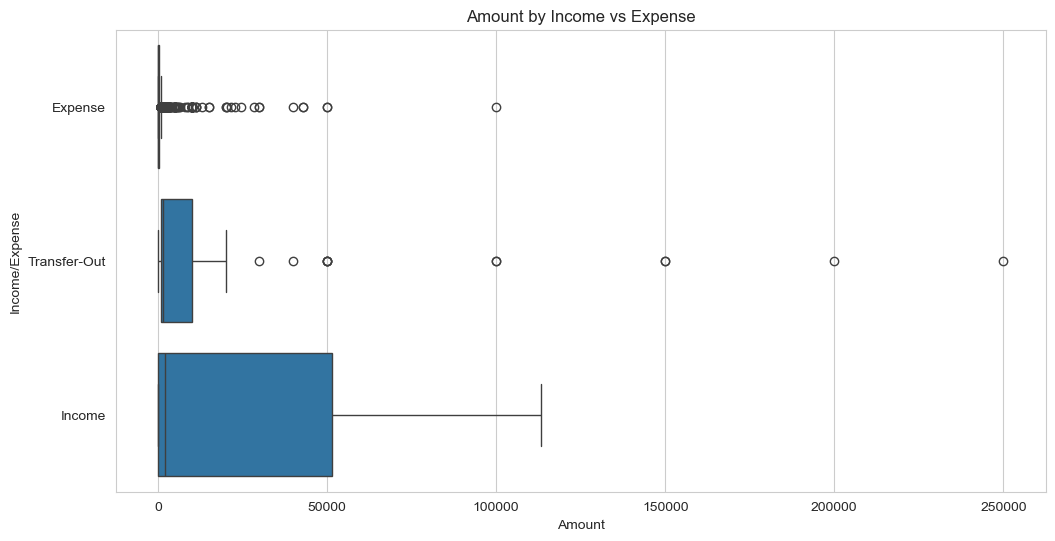

In [23]:
sns.boxplot(data=df, x="Amount", y="Income/Expense")
plt.title("Amount by Income vs Expense")
plt.show()


Time Series Analysis

Monthly Trend

C:\Users\DELL\AppData\Local\Temp\ipykernel_22140\3353339329.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample("M", on="Date")["Amount"].sum()


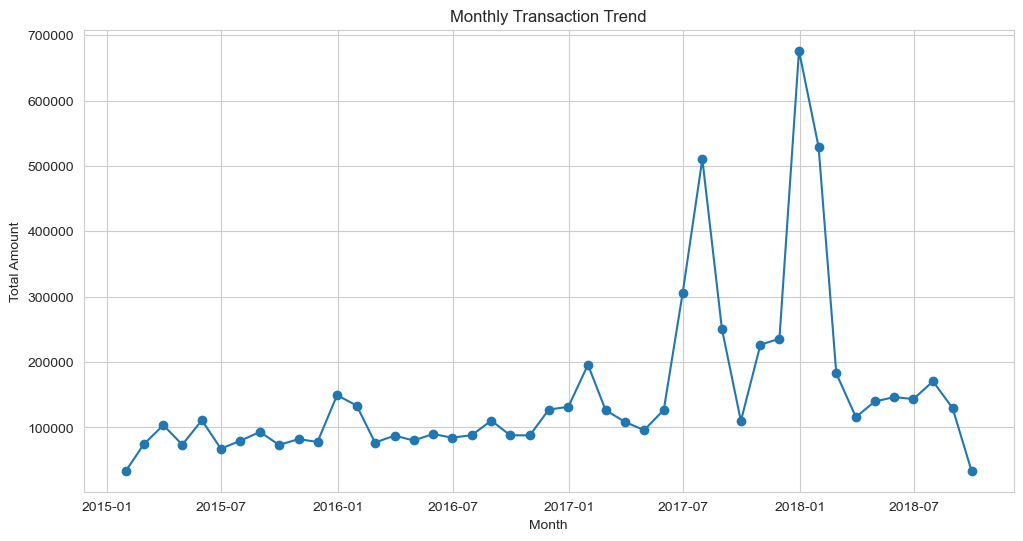

In [24]:
monthly_data = df.resample("M", on="Date")["Amount"].sum()

plt.plot(monthly_data.index, monthly_data, marker="o")
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.grid(True)
plt.show()


Daily Trend

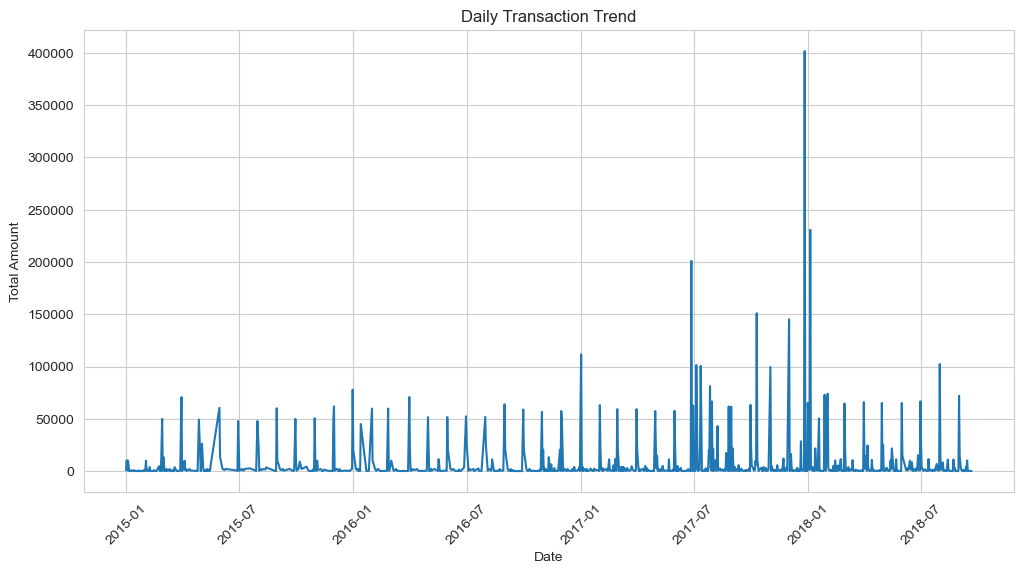

In [25]:
daily_data = df.groupby(df["Date"].dt.date)["Amount"].sum()

plt.plot(daily_data.index, daily_data)
plt.title("Daily Transaction Trend")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Correlation Analysis

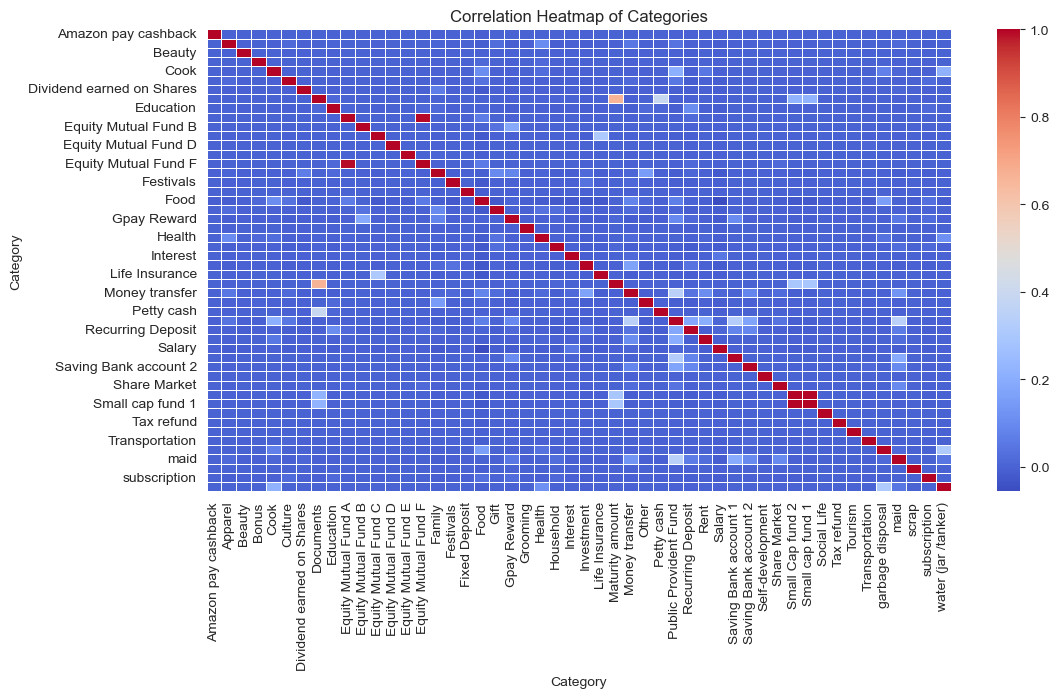

In [26]:
pivot_table = df.pivot_table(
    index="Date",
    columns="Category",
    values="Amount",
    aggfunc="sum",
    fill_value=0
)

correlation_matrix = pivot_table.corr()

sns.heatmap(correlation_matrix, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Categories")
plt.show()


In [27]:
print("Total Transactions:", df.shape[0])
print("Total Expense:", df[df["Income/Expense"]=="Expense"]["Amount"].sum())
print("Total Income:", df[df["Income/Expense"]=="Income"]["Amount"].sum())


Total Transactions: 2452
Total Expense: 1955380.5300000003
Total Income: 3042397.3499999996
